# Bài 2.2 — Classification và threshold

**Mục tiêu:** huấn luyện Logistic Regression trên Breast Cancer; đánh giá phân loại và quan sát tác động của 5 ngưỡng quyết định.

**Đề bài:** [Đào tạo AI - Security](https://docs.google.com/document/d/1bmBCggHgg5WIE0FH0iNsDSfu60QtCeFE/edit).

Luồng: nạp dữ liệu → chia train/test 80/20 → chuẩn hóa bằng thống kê train → train Logistic Regression → đánh giá → lấy xác suất → tự áp threshold → lập bảng và vẽ Precision/Recall → liên hệ AV endpoint.

**Quy ước positive:** giữ nguyên nhãn dataset: `0 = malignant` (positive), `1 = benign` (negative). Precision, Recall, F1 đều tính cho **nhãn 0**. Phần thảo luận giả định positive tương ứng với malware và negative tương ứng với phần mềm sạch; dữ liệu thực nghiệm vẫn là Breast Cancer, không phải dữ liệu malware.

## 1. Thư viện và cấu hình

Cố định seed 42 và đúng năm threshold đề yêu cầu. `max_iter=1000` là giới hạn số vòng lặp để solver có đủ thời gian hội tụ; không phải yêu cầu tự viết Gradient Descent.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

SEED = 42
TEST_SIZE = 0.20
POSITIVE_LABEL = 0
NEGATIVE_LABEL = 1
THRESHOLDS = [0.2, 0.3, 0.5, 0.7, 0.8]
np.random.seed(SEED)

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__, '| pandas:', pd.__version__)
print('scikit-learn:', sklearn.__version__, '| Matplotlib:', matplotlib.__version__)

Python: 3.13.7
NumPy: 2.5.2 | pandas: 3.0.5
scikit-learn: 1.9.0 | Matplotlib: 3.11.1


## 2. Nạp dữ liệu và chia train/test

`stratify=y` giữ tỷ lệ hai class gần với dữ liệu ban đầu. Chia trước khi fit scaler để tránh thông tin test lọt vào bước chuẩn bị dữ liệu. Bài dùng train/test theo đề; không tạo validation và không tìm siêu tham số.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y,
)

print('Số sample:', X.shape[0], '| Số feature:', X.shape[1])
print('Nhãn:', dict(enumerate(data.target_names)))
print('Train:', X_train.shape, '| Test:', X_test.shape)
split_counts = pd.DataFrame({
    'Toàn bộ': np.bincount(y, minlength=2),
    'Train': np.bincount(y_train, minlength=2),
    'Test': np.bincount(y_test, minlength=2),
}, index=['0: malignant (positive)', '1: benign (negative)'])
display(split_counts)

Số sample: 569 | Số feature: 30
Nhãn: {0: np.str_('malignant'), 1: np.str_('benign')}
Train: (455, 30) | Test: (114, 30)


,Toàn bộ,Train,Test
0: malignant (positive),212,170,42
1: benign (negative),357,285,72


## 3. Chuẩn hóa và huấn luyện

`StandardScaler` học mean và độ lệch chuẩn của từng feature từ **train**. Cả train và test dùng lại các thống kê này. Logistic Regression học trên train đã chuẩn hóa.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED)
model.fit(X_train_scaled, y_train)
print('Số sample scaler dùng để fit:', scaler.n_samples_seen_)
print('Thứ tự class của model:', model.classes_)
print('Số vòng lặp solver đã chạy:', model.n_iter_)

Số sample scaler dùng để fit: 455.0
Thứ tự class của model: [0 1]
Số vòng lặp solver đã chạy: [19]


## 4. Đánh giá ban đầu trên test

Accuracy tính trên tất cả mẫu. Precision, Recall và F1 dùng `pos_label=0`, tức malignant.

Để tránh đọc nhầm Confusion Matrix, đặt thứ tự nhãn là `[negative, positive] = [1, 0]`. Hàng là nhãn thật, cột là dự đoán; ma trận theo thứ tự này là `[[TN, FP], [FN, TP]]`.

In [4]:
y_pred = model.predict(X_test_scaled)
baseline = pd.DataFrame([{
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
    'Recall': recall_score(y_test, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
    'F1': f1_score(y_test, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
}])
display(baseline.round(6))

baseline_cm = confusion_matrix(y_test, y_pred, labels=[NEGATIVE_LABEL, POSITIVE_LABEL])
display(pd.DataFrame(
    baseline_cm,
    index=['Thật: benign (negative)', 'Thật: malignant (positive)'],
    columns=['Đoán: benign (negative)', 'Đoán: malignant (positive)'],
))

,Accuracy,Precision,Recall,F1
0,0.982456,0.97619,0.97619,0.97619


,Đoán: benign (negative),Đoán: malignant (positive)
Thật: benign (negative),71,1
Thật: malignant (positive),1,41


## 5. Tự áp dụng năm threshold

`predict_proba` trả một cột cho mỗi nhãn theo `model.classes_`. Lấy đúng cột xác suất của **nhãn 0**, không mặc định cột thứ hai là positive.

Quy tắc: nếu `P(malignant) >= threshold` thì dự đoán `0` (positive), ngược lại dự đoán `1` (negative). Giữ nguyên model và tập test ở cả năm lần; chỉ thay threshold.

- TP: malignant được dự đoán malignant.
- FP: benign bị dự đoán malignant.
- TN: benign được dự đoán benign.
- FN: malignant bị dự đoán benign.
- Precision = TP / (TP + FP); Recall = TP / (TP + FN).
- F1 = 2 × Precision × Recall / (Precision + Recall).

`zero_division=0` quy ước điểm bằng 0 nếu mẫu số không xác định, để code vẫn chạy được khi thay input.

In [5]:
positive_column = np.flatnonzero(model.classes_ == POSITIVE_LABEL).item()
positive_proba = model.predict_proba(X_test_scaled)[:, positive_column]

rows = []
for threshold in THRESHOLDS:
    threshold_pred = np.where(
        positive_proba >= threshold, POSITIVE_LABEL, NEGATIVE_LABEL,
    )
    tn, fp, fn, tp = confusion_matrix(
        y_test, threshold_pred, labels=[NEGATIVE_LABEL, POSITIVE_LABEL],
    ).ravel()
    rows.append({
        'Threshold': threshold,
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'Precision': precision_score(y_test, threshold_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        'Recall': recall_score(y_test, threshold_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        'F1': f1_score(y_test, threshold_pred, pos_label=POSITIVE_LABEL, zero_division=0),
    })

threshold_results = pd.DataFrame(rows)
display(threshold_results.round(6))

,Threshold,TP,FP,TN,FN,Precision,Recall,F1
0,0.2,41,6,66,1,0.872340,0.976190,0.921348
1,0.3,41,5,67,1,0.891304,0.976190,0.931818
2,0.5,41,1,71,1,0.976190,0.976190,0.976190
3,0.7,40,0,72,2,1.000000,0.952381,0.975610
4,0.8,40,0,72,2,1.000000,0.952381,0.975610


## 6. Vẽ Precision và Recall theo threshold

Trục ngang là năm threshold được chỉ định, trục dọc là giá trị metric từ 0 đến 1. Các đoạn nối giúp đọc xu hướng giữa các điểm đã đo.

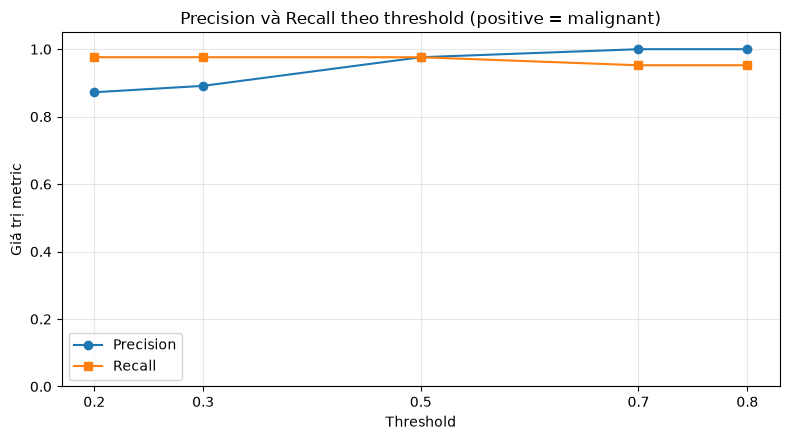

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(threshold_results['Threshold'], threshold_results['Precision'], marker='o', label='Precision')
ax.plot(threshold_results['Threshold'], threshold_results['Recall'], marker='s', label='Recall')
ax.set(title='Precision và Recall theo threshold (positive = malignant)',
       xlabel='Threshold', ylabel='Giá trị metric', ylim=(0, 1.05))
ax.set_xticks(THRESHOLDS)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / 'precision_recall_threshold.png', dpi=150)
plt.show()

## 7. Liên hệ AV endpoint

Trong phần giả định, **positive = malware**, **negative = phần mềm sạch**:

- **Threshold thấp:** dễ gắn nhãn malware hơn, nên số malware phát hiện được tăng hoặc giữ nguyên, số bỏ lọt (FN) giảm hoặc giữ nguyên. Đổi lại, FP có thể tăng: antivirus cảnh báo hoặc chặn nhầm ứng dụng sạch, làm gián đoạn công việc và tăng thời gian xử lý cảnh báo.
- **Threshold cao:** cần xác suất lớn hơn mới cảnh báo. FP giảm hoặc giữ nguyên, ít làm phiền người dùng hơn; nhưng FN có thể tăng, tức malware có thể không bị cảnh báo hoặc chặn và tiếp tục hoạt động.
- Recall không tăng khi nâng threshold trên cùng một tập xác suất. Precision thường được kỳ vọng tăng nhưng không bảo đảm tăng ở mọi ngưỡng trên dữ liệu hữu hạn; cần đọc bảng thực tế.

Năm ngưỡng trong bài là thí nghiệm theo đề trên test, không dùng để tuyên bố một ngưỡng tối ưu cho sản phẩm. Kết quả Breast Cancer minh họa sự đánh đổi, không đo hiệu quả của antivirus thực tế. Số liệu và nhận xét cụ thể nằm trong [report.md](report.md).